# IMDB Sentiment Classification — Finding the Best Model with AutoGluon

**Kaggle-friendly notebook.** This trains and compares multiple AutoML approaches to find the
best sentiment classifier on the IMDB dataset (50k reviews, balanced pos/neg):

1. **AutoGluon `TabularPredictor`** on raw text — auto feature engineering + multi-layer stacked ensemble (CPU-friendly).
2. **AutoGluon `MultiModalPredictor`** — fine-tunes a pretrained transformer (needs GPU; auto-skips if no GPU).

We then compare both on a held-out test set and report the winner.

> **Kaggle setup tips**
> - Add the IMDB dataset via *Add Input* (the file `IMDB_Dataset.csv` should land under `/kaggle/input/...`). The path is auto-detected below.
> - For the MultiModal (transformer) section, enable a **GPU accelerator** under *Settings → Accelerator*. Without a GPU that section is skipped automatically.
> - Turn **Internet ON** if you want the transformer weights to download.


In [1]:
## 0. Install AutoGluon

In [1]:
# AutoGluon isn't pre-installed on Kaggle by default. This installs it quietly.
# (If your Kaggle image already has it, this is a no-op.)
import importlib.util, sys

if importlib.util.find_spec("autogluon") is None:
    !pip install -q -U pip
    !pip install -q autogluon.tabular autogluon.multimodal
    print("AutoGluon installed.")
else:
    print("AutoGluon already available.")


AutoGluon installed.


## 1. Imports & environment check

In [3]:
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 150)

# GPU detection (determines whether we run the transformer section)
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
except Exception:
    GPU_AVAILABLE = False

print("GPU available:", GPU_AVAILABLE)


GPU available: False


## 2. Locate & load the dataset (Kaggle path auto-detection)

In [4]:
# Try common Kaggle input locations, then fall back to the working dir.
candidates = glob.glob("/kaggle/input/**/IMDB_Dataset.csv", recursive=True)
candidates += glob.glob("/kaggle/input/**/*.csv", recursive=True)
candidates += ["IMDB_Dataset.csv"]

DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find IMDB_Dataset.csv. Add it via 'Add Input' on Kaggle "
        "or place it in the working directory."
    )

print("Using dataset at:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


Using dataset at: /kaggle/input/datasets/mishasondhi/imdb-dataset/IMDB_Dataset.csv
(50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


## 3. Quick EDA

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


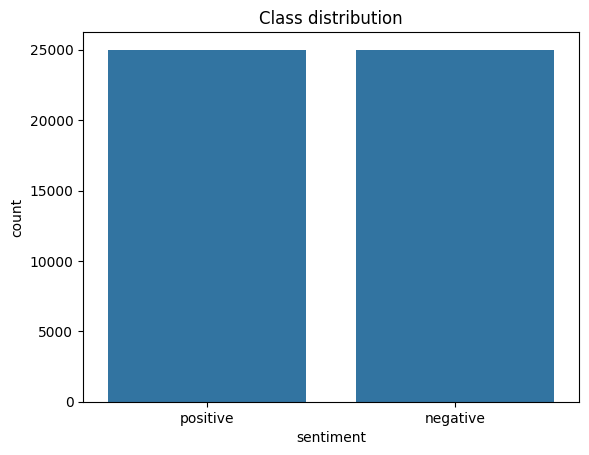

In [5]:
print(df["sentiment"].value_counts())
sns.countplot(x="sentiment", data=df)
plt.title("Class distribution")
plt.show()


count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_len, dtype: float64


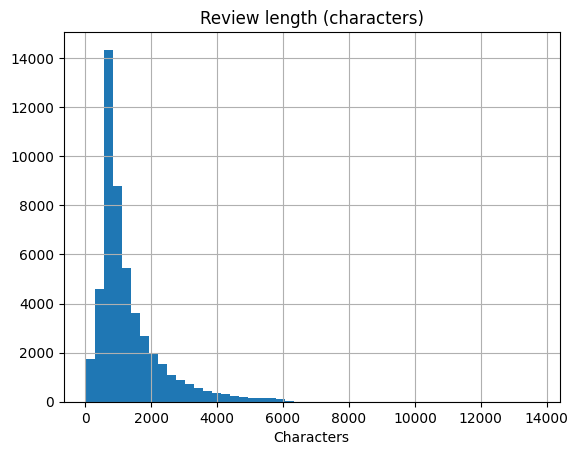

In [6]:
df["review_len"] = df["review"].str.len()
print(df["review_len"].describe())
df["review_len"].hist(bins=50)
plt.title("Review length (characters)")
plt.xlabel("Characters")
plt.show()
df = df.drop(columns=["review_len"])


## 4. Light cleaning & split

We only strip HTML artifacts (`<br />` etc.) — AutoGluon handles the heavy lifting of feature
generation and tokenization internally, so aggressive preprocessing is unnecessary and can even
remove useful signal.

In [7]:
import re

def clean_text(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review"] = df["review"].apply(clean_text)

train_df, test_df = train_test_split(
    df[["review", "sentiment"]],
    test_size=0.2, random_state=42, stratify=df["sentiment"]
)
print("Train:", train_df.shape, "| Test:", test_df.shape)
train_df.head(2)


Train: (40000, 2) | Test: (10000, 2)


,review,sentiment
47808,I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was p...,positive
20154,"I can't believe that I let myself into this movie to accomplish a favor my friends ask me early this April 14, 2007. This movie certainly a pain i...",negative


In [8]:
LABEL = "sentiment"

# Numeric ground-truth for ROC-AUC computation later (positive = 1)
y_test_binary = (test_df[LABEL] == "positive").astype(int).values


## 5. Model A — AutoGluon `TabularPredictor`

Feeds the raw text column directly. AutoGluon auto-detects it as text, generates features, and
trains a multi-layer **stacked ensemble** of LightGBM / XGBoost / CatBoost / neural nets, etc.

- `presets="best_quality"` maximizes accuracy (heavier). Use `"medium_quality"` for a faster run.
- `time_limit` caps total training seconds — tune to your Kaggle session budget.

In [9]:
from autogluon.tabular import TabularPredictor

TABULAR_TIME_LIMIT = 1800   # seconds; lower for a quicker run
TABULAR_PRESET = "best_quality"

start = time.time()
tabular_predictor = TabularPredictor(
    label=LABEL,
    eval_metric="accuracy",
    path="ag_tabular_imdb",
).fit(
    train_data=train_df,
    presets=TABULAR_PRESET,
    time_limit=TABULAR_TIME_LIMIT,
)
print(f"\nTabularPredictor training took {time.time() - start:.1f}s")


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat May 30 15:40:53 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       29.58 GB / 31.35 GB (94.4%)
Disk Space Avail:   18.64 GB / 19.52 GB (95.5%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` v


TabularPredictor training took 1923.9s


In [10]:
# Per-model leaderboard on the held-out test set
tabular_lb = tabular_predictor.leaderboard(test_df, silent=True)
tabular_lb


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1,0.9072,0.898400,accuracy,39.385005,10.711815,593.399081,39.385005,10.711815,593.399081,1,True,1
1,WeightedEnsemble_L2,0.9072,0.898400,accuracy,39.388365,10.715386,593.517738,0.003360,0.003572,0.118657,2,True,3
2,WeightedEnsemble_L3,0.9072,0.898400,accuracy,39.389258,10.715575,593.567832,0.004253,0.003760,0.168752,3,True,5
3,LightGBMXT_BAG_L2,0.8889,0.877050,accuracy,81.353243,19.595947,1111.358233,10.746489,4.647192,263.142290,2,True,4
4,LightGBM_BAG_L1,0.7428,0.733925,accuracy,31.221750,4.236939,254.816863,31.221750,4.236939,254.816863,1,True,2


In [11]:
# Evaluate the tabular ensemble
tab_pred = tabular_predictor.predict(test_df)
tab_proba = tabular_predictor.predict_proba(test_df)["positive"].values

tab_acc = accuracy_score(test_df[LABEL], tab_pred)
tab_f1 = f1_score(test_df[LABEL], tab_pred, pos_label="positive")
tab_auc = roc_auc_score(y_test_binary, tab_proba)

print(f"TabularPredictor  Accuracy: {tab_acc:.4f} | F1: {tab_f1:.4f} | ROC-AUC: {tab_auc:.4f}")
print()
print(classification_report(test_df[LABEL], tab_pred))


TabularPredictor  Accuracy: 0.9072 | F1: 0.9079 | ROC-AUC: 0.9680

              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 6. Compare models & pick the winner

In [13]:
results = [{"model": "AutoGluon Tabular (ensemble)",
            "accuracy": tab_acc, "f1": tab_f1, "roc_auc": tab_auc}]

comparison = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

best_row = comparison.iloc[0]
print(f"\n>>> Best model: {best_row['model']} (accuracy = {best_row['accuracy']:.4f})")


                       model  accuracy     f1  roc_auc
AutoGluon Tabular (ensemble)    0.9072 0.9079 0.967975

>>> Best model: AutoGluon Tabular (ensemble) (accuracy = 0.9072)


## 7. Confusion matrix for the best model

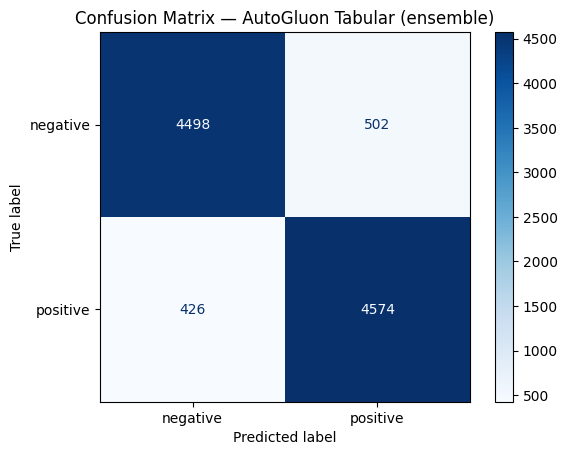

In [16]:
best_predictor = tabular_predictor

best_pred = best_predictor.predict(test_df)
cm = confusion_matrix(test_df[LABEL], best_pred, labels=["negative", "positive"])
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_row['model']}")
plt.show()


## 8. Feature importance (Tabular model)

In [17]:
# Permutation feature importance for the tabular ensemble.
# On raw-text input AutoGluon exposes generated text features; this shows which matter most.
try:
    fi = tabular_predictor.feature_importance(test_df)
    print(fi.head(20))
except Exception as e:
    print("Feature importance unavailable:", e)


Computing feature importance via permutation shuffling for 1 features using 5000 rows with 5 shuffle sets...
	198.55s	= Expected runtime (39.71s per shuffle set)
	198.25s	= Actual runtime (Completed 5 of 5 shuffle sets)


        importance    stddev       p_value  n  p99_high   p99_low
review      0.4042  0.003356  5.699449e-10  5  0.411109  0.397291


## 9. Inference helper & save

In [18]:
def predict_sentiment(text: str, predictor=None):
    predictor = predictor or best_predictor
    cleaned = clean_text(text)
    return predictor.predict(pd.DataFrame({"review": [cleaned]}))[0]

samples = [
    "This movie was an absolute masterpiece, the acting was superb!",
    "Complete waste of time. Terrible plot and even worse acting.",
    "It was okay, some good moments but dragged on too long.",
]
for s in samples:
    print(f"{predict_sentiment(s):>8}  <-  {s}")


positive  <-  This movie was an absolute masterpiece, the acting was superb!
negative  <-  Complete waste of time. Terrible plot and even worse acting.
negative  <-  It was okay, some good moments but dragged on too long.


In [19]:
# Predictors are already saved to their `path` directories during fit():
#   ag_tabular_imdb/  
print("Saved: ag_tabular_imdb/")


Saved: ag_tabular_imdb/


## Notes on getting the best possible score

- **GPU + MultiModal** is the single biggest lever — expect ~93–95% vs ~91–92% for the tabular ensemble.
- Increase `time_limit` on either predictor for a more thorough search.
- For MultiModal, try a stronger backbone via `hyperparameters={"model.hf_text.checkpoint_name": "microsoft/deberta-v3-base"}` in `.fit()`.
- **Ensemble** the tabular and transformer predictions (e.g., average probabilities) for a final nudge.
- Watch the Kaggle session time limit (9h) and GPU quota when using `best_quality` presets.
